In [2]:
import pandas as pd

sheets = pd.read_excel("../data/raw/online_retail_II.xlsx", sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)
df.shape

(1067371, 8)

In [3]:
df.to_csv("../data/raw/online_retail_II.csv", index=False)

In [4]:
df = pd.read_csv("../data/raw/online_retail_II.csv", parse_dates=["InvoiceDate"])

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 117.3 MB


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [10]:
df.duplicated().sum()

np.int64(34335)

In [11]:
df["Invoice"] = df["Invoice"].astype(str)
cancelled = df[df["Invoice"].str.startswith("C")]
print("Cancelled rows:", len(cancelled))
cancelled.head()

Cancelled rows: 19494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [12]:
df[df["Price"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


In [13]:
clean = df.copy()
print("Start:", len(clean))

Start: 1067371


In [14]:
clean = clean.dropna(subset=["Customer ID"])
print("After dropping missing Customer ID:", len(clean))

After dropping missing Customer ID: 824364


In [15]:
clean = clean.drop_duplicates()
print("After dropping duplicates:", len(clean))

After dropping duplicates: 797885


In [16]:
clean = clean[~clean["Invoice"].str.startswith("C")]
print("After removing cancellations:", len(clean))

After removing cancellations: 779495


In [17]:
clean = clean[(clean["Quantity"] > 0) & (clean["Price"] > 0)]
print("After removing bad Quantity/Price:", len(clean))

After removing bad Quantity/Price: 779425


In [18]:
clean["Customer ID"] = clean["Customer ID"].astype(int)

In [19]:
clean["TotalPrice"] = clean["Quantity"] * clean["Price"]

In [20]:
print("Rows:", len(clean))
print("Unique customers:", clean["Customer ID"].nunique())
print("Date range:", clean["InvoiceDate"].min(), "to", clean["InvoiceDate"].max())
clean.describe()

Rows: 779425
Unique customers: 5878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Quantity,InvoiceDate,Price,Customer ID,TotalPrice
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [21]:
clean.to_csv("../data/processed_clean.csv", index=False)

In [22]:
clean = pd.read_csv("../data/processed_clean.csv", parse_dates=["InvoiceDate"])

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

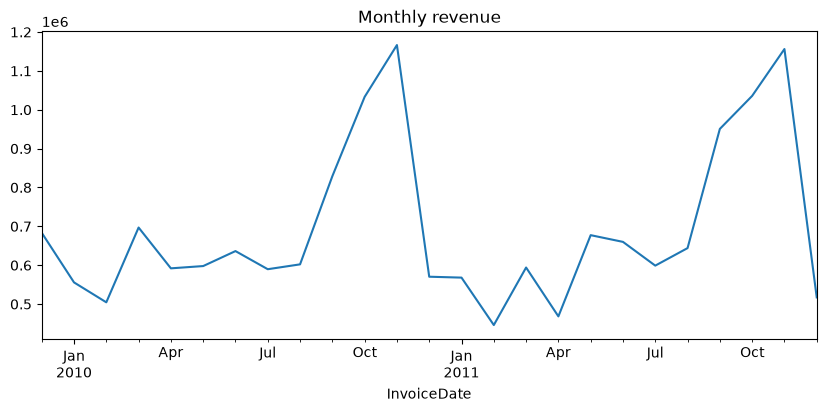

In [25]:
monthly = clean.set_index("InvoiceDate")["TotalPrice"].resample("ME").sum()
monthly.plot(figsize=(10, 4), title="Monthly revenue")
plt.show()

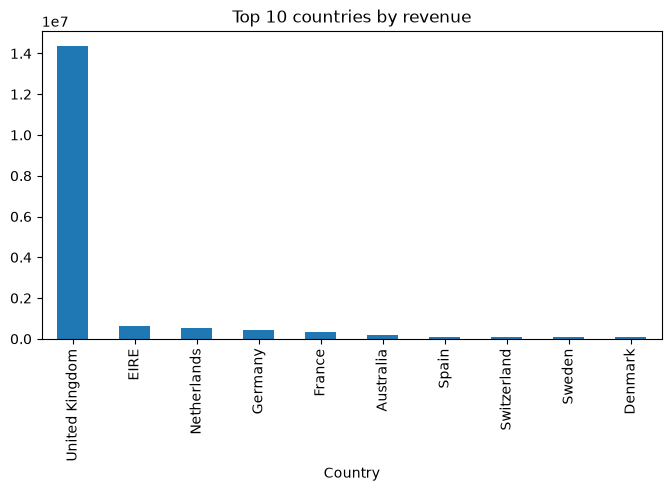

In [26]:
clean.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar", figsize=(8,4), title="Top 10 countries by revenue")
plt.show()

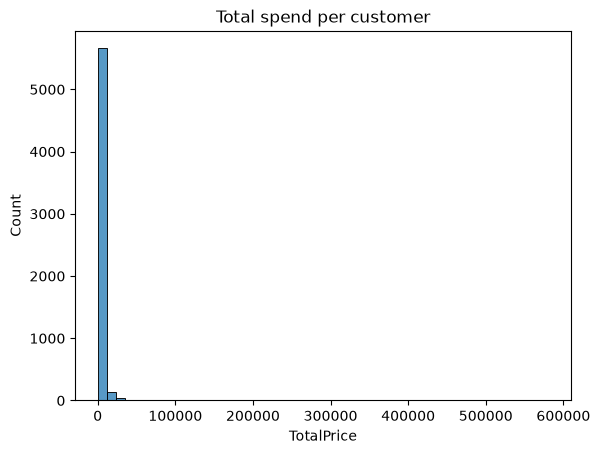

In [27]:
cust_spend = clean.groupby("Customer ID")["TotalPrice"].sum()
sns.histplot(cust_spend, bins=50)
plt.title("Total spend per customer")
plt.show()

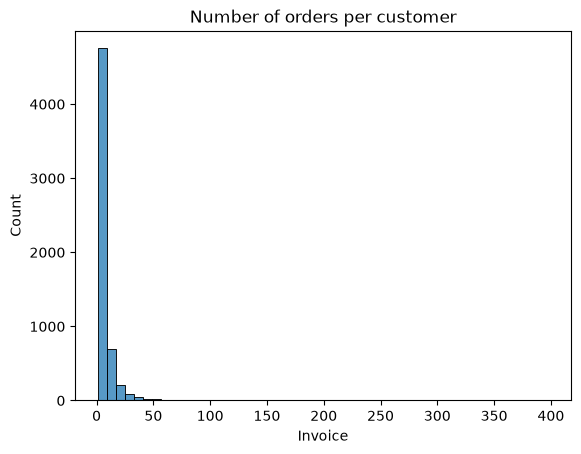

In [28]:
orders = clean.groupby("Customer ID")["Invoice"].nunique()
sns.histplot(orders, bins=50)
plt.title("Number of orders per customer")
plt.show()

In [29]:
import pandas as pd
import numpy as np

clean = pd.read_csv("../data/processed_clean.csv", parse_dates=["InvoiceDate"])

end_date = clean["InvoiceDate"].max()
cutoff = end_date - pd.Timedelta(days=90)
print("Dataset ends:", end_date)
print("Cutoff date :", cutoff)

Dataset ends: 2011-12-09 12:50:00
Cutoff date : 2011-09-10 12:50:00


In [30]:
history = clean[clean["InvoiceDate"] < cutoff]      # used for features
future  = clean[clean["InvoiceDate"] >= cutoff]     # used only for the label
print("History rows:", len(history), "| Future rows:", len(future))

History rows: 620572 | Future rows: 158853


In [31]:
orders = (history
          .groupby(["Customer ID", "Invoice"])
          .agg(InvoiceDate=("InvoiceDate", "max"),
               OrderValue=("TotalPrice", "sum"))
          .reset_index())
orders.head()

,Customer ID,Invoice,InvoiceDate,OrderValue
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


In [32]:
features = orders.groupby("Customer ID").agg(
    LastPurchase=("InvoiceDate", "max"),
    FirstPurchase=("InvoiceDate", "min"),
    Frequency=("Invoice", "nunique"),
    Monetary=("OrderValue", "sum"),
    AvgOrderValue=("OrderValue", "mean"),
)

# Recency and tenure are measured from the cutoff date
features["Recency"] = (cutoff - features["LastPurchase"]).dt.days
features["Tenure"]  = (cutoff - features["FirstPurchase"]).dt.days

# Number of different products ever bought
features["UniqueProducts"] = history.groupby("Customer ID")["StockCode"].nunique()

features = features.drop(columns=["LastPurchase", "FirstPurchase"])
features.head()

,Frequency,Monetary,AvgOrderValue,Recency,Tenure,UniqueProducts
Customer ID,,,,,,
12346,12,77556.46,6463.038333,235,635,27
12347,6,3402.39,567.065000,39,313,107
12348,4,1709.40,427.350000,158,347,25
12349,3,2671.14,890.380000,317,498,90
12350,1,334.40,334.400000,219,219,17


In [33]:
buyers_in_future = set(future["Customer ID"])
features["Purchased_Next_90d"] = features.index.isin(buyers_in_future).astype(int)

features["Purchased_Next_90d"].value_counts()

Purchased_Next_90d
0    2989
1    2292
Name: count, dtype: int64

In [34]:
features["Purchased_Next_90d"].value_counts(normalize=True)

Purchased_Next_90d
0    0.565991
1    0.434009
Name: proportion, dtype: float64

In [35]:
print("Customers:", len(features))
print(features.isnull().sum())
features.describe()

Customers: 5281
Frequency             0
Monetary              0
AvgOrderValue         0
Recency               0
Tenure                0
UniqueProducts        0
Purchased_Next_90d    0
dtype: int64


,Frequency,Monetary,AvgOrderValue,Recency,Tenure,UniqueProducts,Purchased_Next_90d
count,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000,5281.000000
mean,5.745692,2637.863286,369.292417,207.282901,431.772770,74.356751,0.434009
std,11.464582,12225.544955,538.206215,175.007174,180.518152,104.968606,0.495673
min,1.000000,2.900000,2.900000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,318.240000,174.668000,49.000000,311.000000,18.000000,0.000000
50%,3.000000,783.580000,276.860000,164.000000,474.000000,41.000000,0.000000
75%,6.000000,2078.540000,409.725000,326.000000,587.000000,92.000000,1.000000
max,309.000000,456780.490000,14844.766667,648.000000,648.000000,2182.000000,1.000000


In [36]:
features.groupby("Purchased_Next_90d")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Purchased_Next_90d,,,
0,274.179324,3.054868,1134.621498
1,120.043194,9.254799,4598.242739


In [37]:
features.to_csv("../data/rfm_features.csv")

In [38]:
import pandas as pd
import numpy as np

features = pd.read_csv("../data/rfm_features.csv", index_col="Customer ID")

seg_cols = ["Recency", "Frequency", "Monetary"]
X = features[seg_cols].copy()

In [39]:
from sklearn.preprocessing import StandardScaler

X_log = np.log1p(X)          # log1p = log(1 + x), safe when a value is 0
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

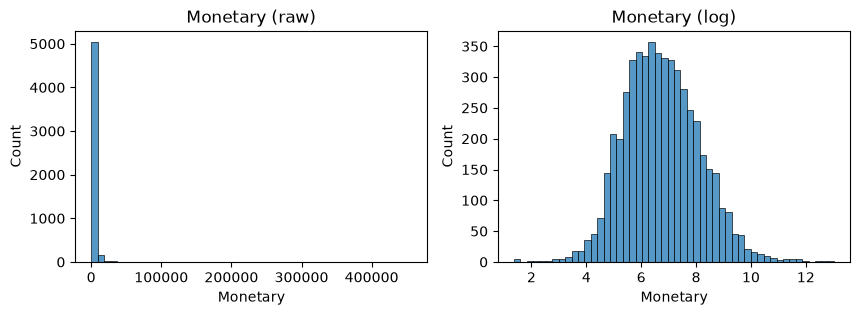

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(X["Monetary"], bins=50, ax=ax[0]).set_title("Monetary (raw)")
sns.histplot(X_log["Monetary"], bins=50, ax=ax[1]).set_title("Monetary (log)")
plt.show()

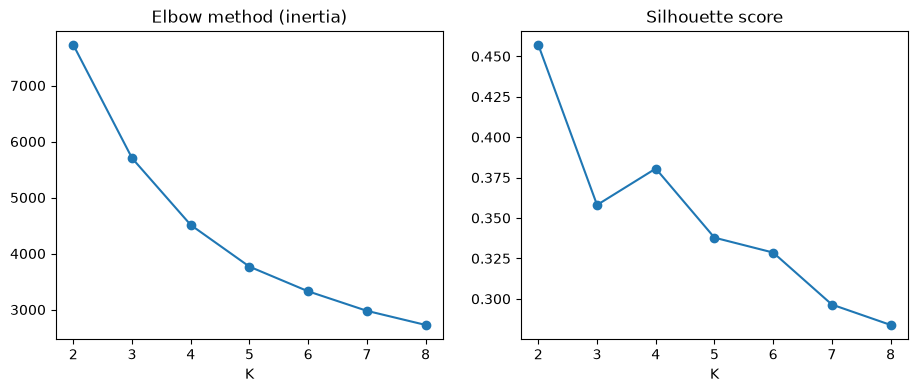

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Elbow method (inertia)")
ax[0].set_xlabel("K")
ax[1].plot(k_range, silhouettes, marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("K")
plt.show()

In [42]:
K = 4   # change this to the K you chose
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
features["Segment"] = kmeans.fit_predict(X_scaled)

features["Segment"].value_counts().sort_index()

Segment
0    1606
1    2128
2     891
3     656
Name: count, dtype: int64

In [43]:
profile = features.groupby("Segment").agg(
    Customers=("Recency", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Bought_Again=("Purchased_Next_90d", "mean"),
).round(1)
profile

,Customers,Recency,Frequency,Monetary,Bought_Again
Segment,,,,,
0,1606,195.3,5.2,2033.7,0.5
1,2128,344.5,1.4,344.8,0.2
2,891,29.9,19.3,10623.3,0.8
3,656,32.4,2.7,709.5,0.6


In [44]:
segment_names = {
    0: "Segment 0 name",
    1: "Segment 1 name",
    2: "Segment 2 name",
    3: "Segment 3 name",
}
features["SegmentName"] = features["Segment"].map(segment_names)

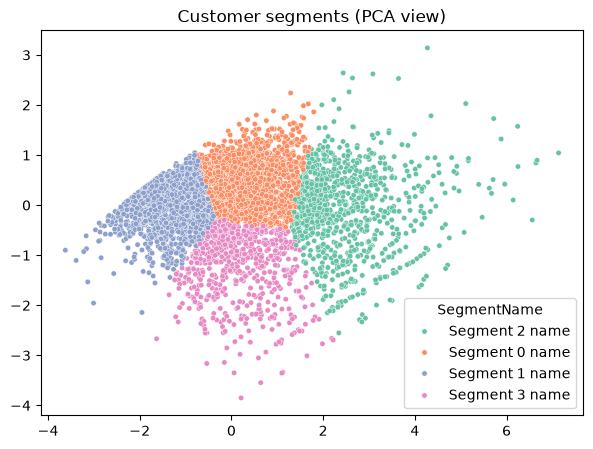

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1],
                hue=features["SegmentName"], palette="Set2", s=15)
plt.title("Customer segments (PCA view)")
plt.show()

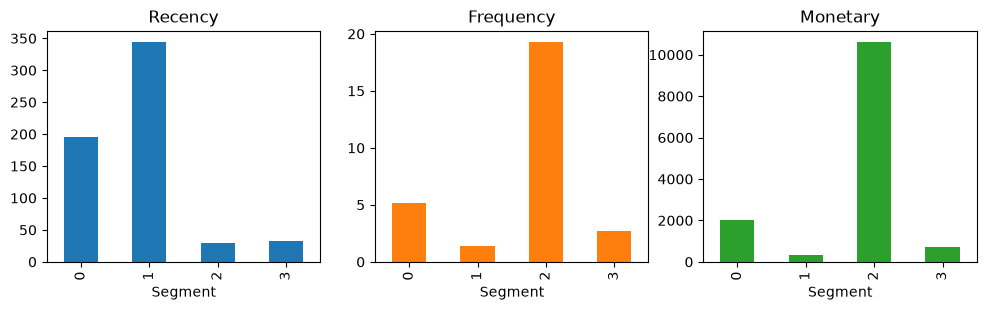

In [46]:
profile[["Recency", "Frequency", "Monetary"]].plot(
    kind="bar", subplots=True, layout=(1, 3), figsize=(12, 3), legend=False)
plt.show()

In [47]:
import joblib

joblib.dump(scaler, "../models/scaler.joblib")
joblib.dump(kmeans, "../models/kmeans.joblib")
features.to_csv("../data/rfm_features_segmented.csv")

In [48]:
import pandas as pd
import numpy as np

features = pd.read_csv("../data/rfm_features_segmented.csv", index_col="Customer ID")

y = features["Purchased_Next_90d"]
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Purchased_Next_90d
0    2989
1    2292
Name: count, dtype: int64
Purchased_Next_90d
0    0.566
1    0.434
Name: proportion, dtype: float64


In [49]:
num_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Tenure", "UniqueProducts"]

X = features[num_cols + ["Segment"]].copy()
X = pd.get_dummies(X, columns=["Segment"], dtype=int)   # segment as 0/1 columns
X.head()

,Recency,Frequency,Monetary,AvgOrderValue,Tenure,UniqueProducts,Segment_0,Segment_1,Segment_2,Segment_3
Customer ID,,,,,,,,,,
12346,235,12,77556.46,6463.038333,635,27,0,0,1,0
12347,39,6,3402.39,567.065000,313,107,1,0,0,0
12348,158,4,1709.40,427.350000,347,25,1,0,0,0
12349,317,3,2671.14,890.380000,498,90,1,0,0,0
12350,219,1,334.40,334.400000,219,17,0,1,0,0


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(4224, 10) (1057, 10)


In [51]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Accuracy if always predicting the majority class:", round(dummy.score(X_test, y_test), 3))

Accuracy if always predicting the majority class: 0.566


In [52]:
from sklearn.metrics import classification_report

def evaluate(name, model):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
    print(classification_report(y_test, pred))
    return model

In [53]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg = make_pipeline(
    FunctionTransformer(np.log1p),
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
log_reg = evaluate("Logistic Regression", log_reg)

=== Logistic Regression ===
ROC-AUC: 0.801
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       598
           1       0.69      0.68      0.69       459

    accuracy                           0.73      1057
   macro avg       0.72      0.72      0.72      1057
weighted avg       0.73      0.73      0.73      1057



In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf = evaluate("Random Forest", rf)

=== Random Forest ===
ROC-AUC: 0.794
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       598
           1       0.69      0.66      0.68       459

    accuracy                           0.72      1057
   macro avg       0.72      0.72      0.72      1057
weighted avg       0.72      0.72      0.72      1057



In [55]:
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg / pos,          # handles class imbalance
    eval_metric="logloss", random_state=42,
)
xgb = evaluate("XGBoost", xgb)

=== XGBoost ===
ROC-AUC: 0.797
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       598
           1       0.70      0.70      0.70       459

    accuracy                           0.74      1057
   macro avg       0.74      0.74      0.74      1057
weighted avg       0.74      0.74      0.74      1057



In [56]:
from sklearn.model_selection import cross_val_score

for name, model in [("LogReg", log_reg), ("RandomForest", rf), ("XGBoost", xgb)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name}: {scores.mean():.3f} ± {scores.std():.3f}")

LogReg: 0.794 ± 0.018
RandomForest: 0.796 ± 0.018
XGBoost: 0.797 ± 0.015


In [57]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=neg / pos, eval_metric="logloss", random_state=42),
    param_distributions=param_dist, n_iter=20, scoring="roc_auc",
    cv=5, random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 3))

best_model = search.best_estimator_

Best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV AUC: 0.804


Test ROC-AUC: 0.8
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       598
           1       0.69      0.71      0.70       459

    accuracy                           0.74      1057
   macro avg       0.73      0.73      0.73      1057
weighted avg       0.74      0.74      0.74      1057



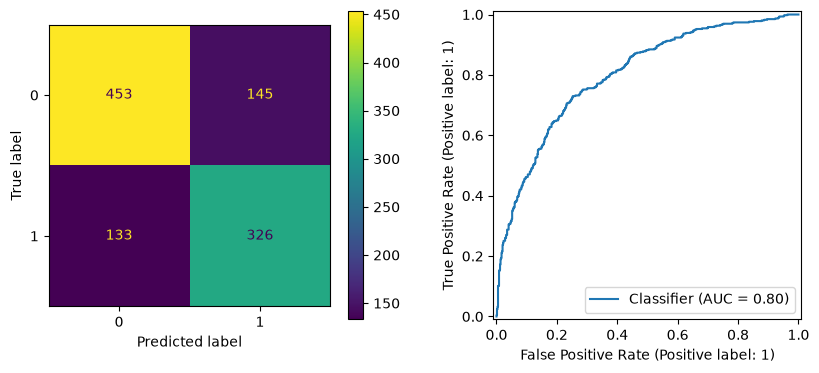

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

proba = best_model.predict_proba(X_test)[:, 1]
pred = best_model.predict(X_test)

print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, pred))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax[0])
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
plt.show()

In [59]:
seg_cols = [c for c in X.columns if c.startswith("Segment_")]

m = XGBClassifier(**search.best_params_, scale_pos_weight=neg / pos,
                  eval_metric="logloss", random_state=42)
m.fit(X_train.drop(columns=seg_cols), y_train)
auc_without = roc_auc_score(y_test, m.predict_proba(X_test.drop(columns=seg_cols))[:, 1])
print("AUC without Segment:", round(auc_without, 3))

AUC without Segment: 0.802


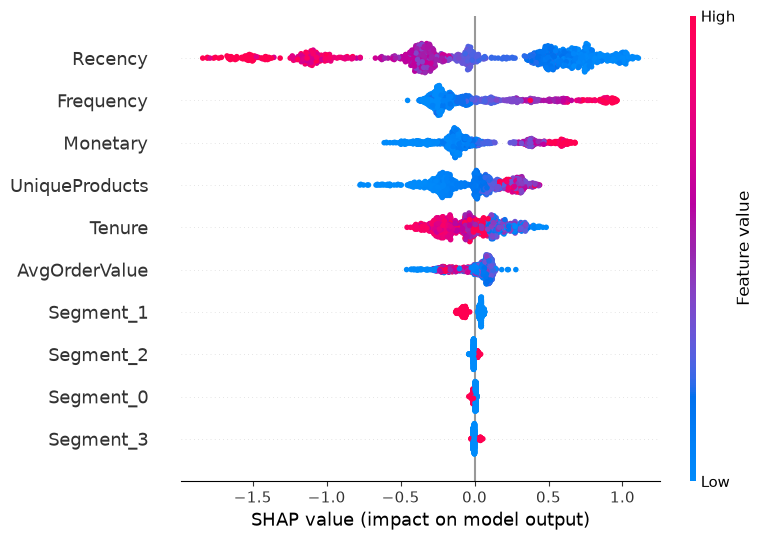

In [60]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [61]:
import joblib

joblib.dump(best_model, "../models/purchase_model.joblib")
joblib.dump(list(X.columns), "../models/feature_columns.joblib")

['../models/feature_columns.joblib']